In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
img_color = cv2.imread('image.png', cv2.IMREAD_COLOR)
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

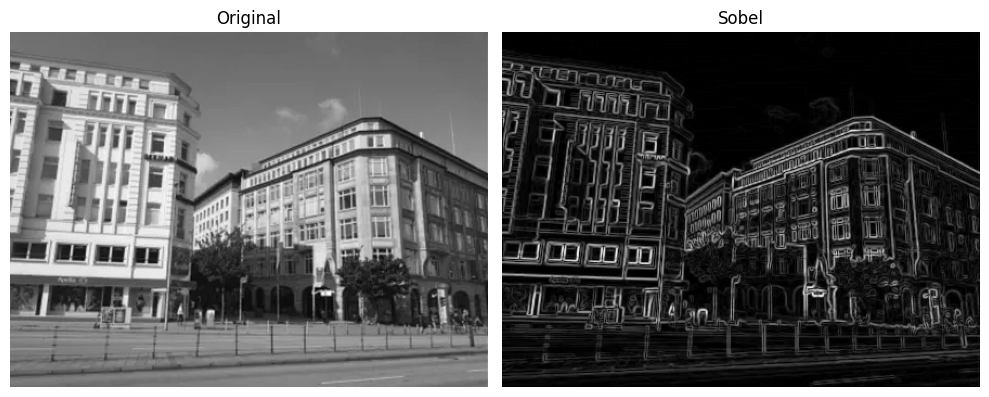

In [14]:
# 1. SOBEL EDGE DETECTION
# ksize=3 uses a 3x3 kernel. We combine X and Y gradients.
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original',)
ax[0].axis('off')
ax[1].imshow(sobel_combined,cmap='gray')
ax[1].set_title('Sobel')
ax[1].axis('off')
plt.tight_layout()
plt.show()

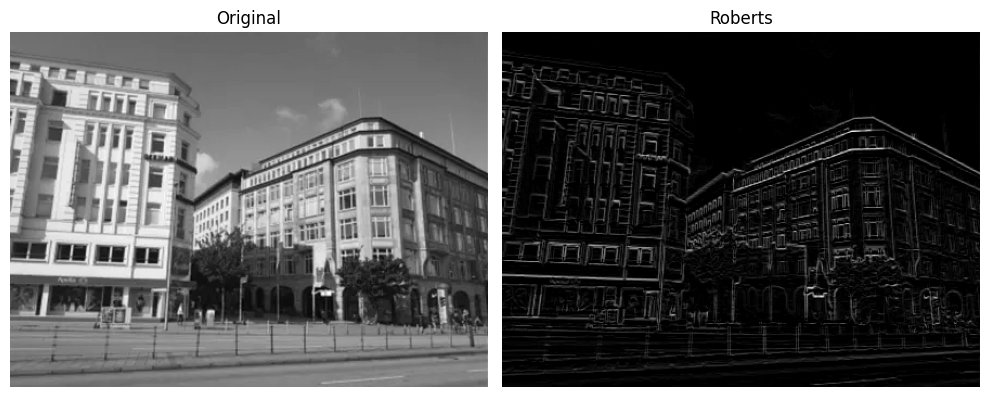

In [15]:

# 2. ROBERTS CROSS OPERATOR
# Roberts kernels are 2x2
kernel_roberts_x = np.array([[1, 0], [0, -1]])
kernel_roberts_y = np.array([[0, 1], [-1, 0]])
roberts_x = cv2.filter2D(img, -1, kernel_roberts_x)
roberts_y = cv2.filter2D(img, -1, kernel_roberts_y)
roberts_combined = cv2.addWeighted(roberts_x, 0.5, roberts_y, 0.5, 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original',)
ax[0].axis('off')
ax[1].imshow(roberts_combined,cmap='gray')
ax[1].set_title('Roberts')
ax[1].axis('off')
plt.tight_layout()
plt.show()

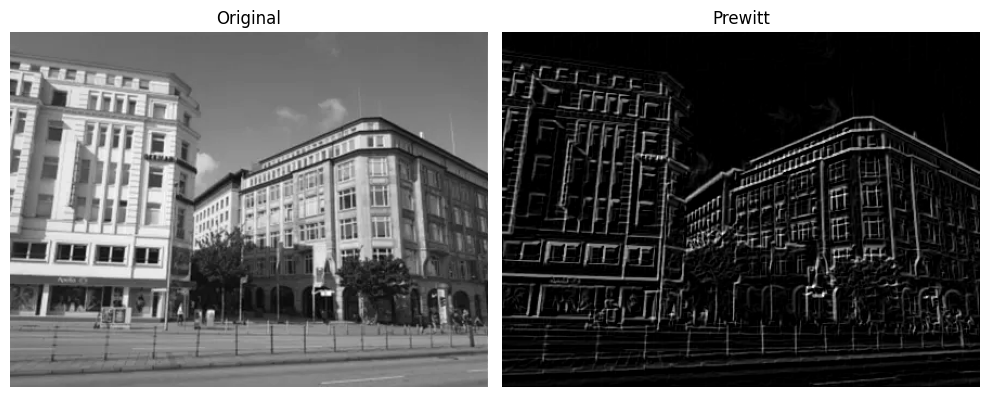

In [16]:
# 3. PREWITT OPERATOR
# Prewitt kernels are 3x3 (similar to Sobel but without the weight of 2)
kernel_prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
kernel_prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
prewitt_x = cv2.filter2D(img, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(img, -1, kernel_prewitt_y)
prewitt_combined = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original',)
ax[0].axis('off')
ax[1].imshow(prewitt_combined,cmap='gray')
ax[1].set_title('Prewitt')
ax[1].axis('off')
plt.tight_layout()
plt.show()

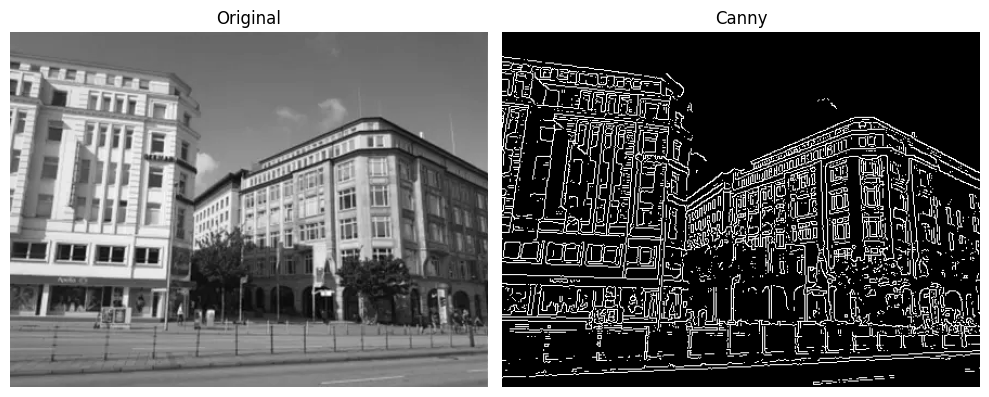

In [17]:
# 4. CANNY EDGE DETECTION
# Requires two thresholds: minVal and maxVal
# It includes internal noise reduction (Gaussian blur)
canny_edges = cv2.Canny(img, 120, 120)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original',)
ax[0].axis('off')
ax[1].imshow(canny_edges,cmap='gray')
ax[1].set_title('Canny')
ax[1].axis('off')
plt.tight_layout()
plt.show()

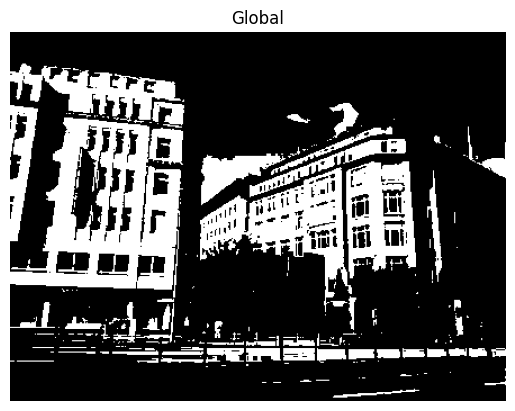

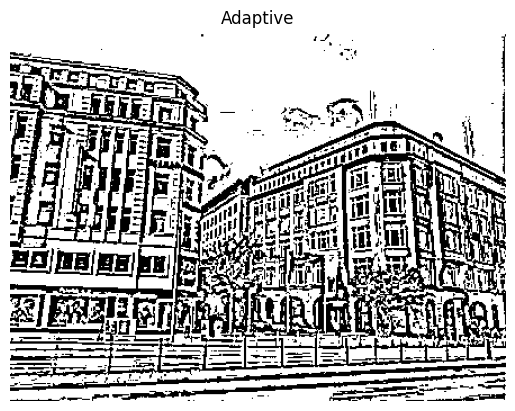

In [23]:
import cv2
import numpy as np

# Load image in grayscale
# img = cv2.imread('image.jpg', 0)

# 1. Global Thresholding (using Otsu's method to find the best value)
ret, global_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Adaptive Thresholding (Gaussian)
# Block Size: size of neighborhood area, C: constant subtracted from mean
adaptive_thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                        cv2.THRESH_BINARY, 11, 2)

plt.imshow(global_thresh, cmap='gray')
plt.title('Global')
plt.axis('off')
plt.show()
plt.imshow(adaptive_thresh, cmap='gray')
plt.title('Adaptive')
plt.axis('off')
plt.show()

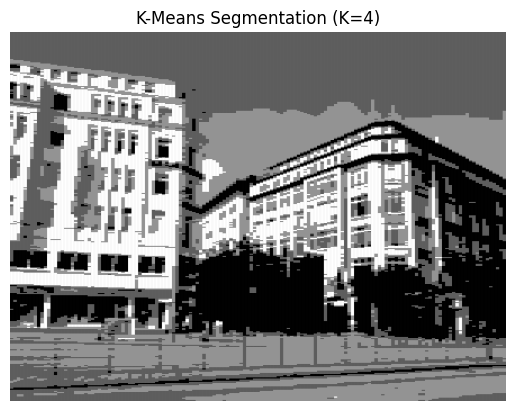

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pixel_values = img.reshape((-1, 3))

k = 4
km = KMeans(n_clusters=k, n_init=10)
labels = km.fit_predict(pixel_values)

centers = np.uint8(km.cluster_centers_)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img.shape)

plt.imshow(segmented_image, cmap='gray')
plt.title(f'K-Means Segmentation (K={k})')
plt.axis('off')
plt.show()

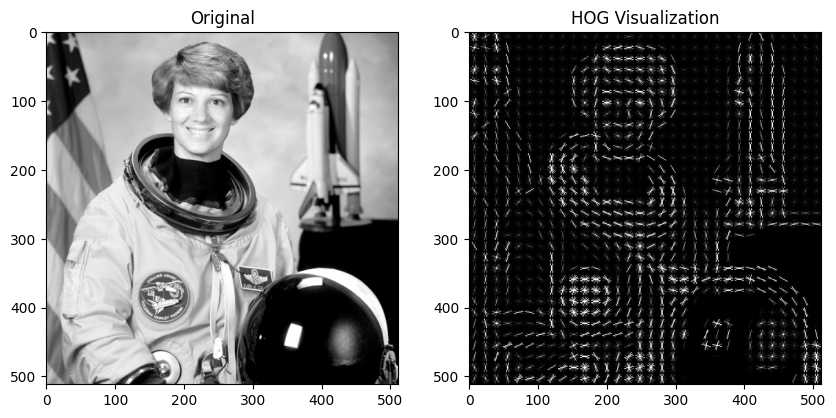

In [20]:
from skimage.feature import hog
from skimage import data, exposure
import matplotlib.pyplot as plt

# Load a sample image
image = data.astronaut() # Color image
gray_image = data.astronaut()[:,:,0] # Grayscale for HOG

# Extract HOG features
# orientations: number of gradient bins
# pixels_per_cell: size of the cell for which gradients are calculated
fd, hog_image = hog(gray_image, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True)

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1).imshow(gray_image, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2).imshow(hog_image_rescaled, cmap='gray'), plt.title('HOG Visualization')
plt.show()

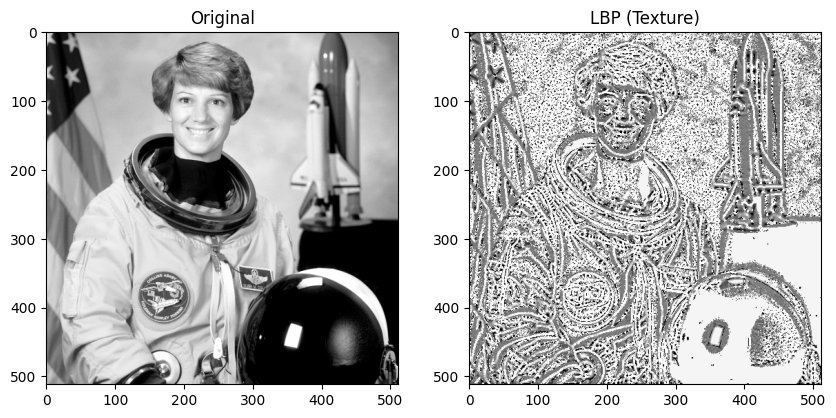

In [21]:
from skimage.feature import local_binary_pattern

# Settings for LBP
radius = 3      # Distance of neighbors
n_points = 8 * radius  # Number of points to sample

# Compute LBP
lbp = local_binary_pattern(gray_image, n_points, radius, method='uniform')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1).imshow(gray_image, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2).imshow(lbp, cmap='gray'), plt.title('LBP (Texture)')
plt.show()